In [ ]:
# ==========================================
# STEP 1: Install & Import Libraries
# ==========================================
!pip install librosa xgboost --quiet

import numpy as np
import pandas as pd
import librosa
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample
from xgboost import XGBClassifier

# ==========================================
# STEP 2: Mount Google Drive
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

# ==========================================
# STEP 3: Extract CREMA-D ZIP
# ==========================================
zip_path = "/content/drive/MyDrive/CREMA-D.zip"   # Change if needed
extract_path = "/content/CREMA-D"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset Extracted Successfully!")

# ==========================================
# STEP 4: Locate AudioWAV Folder
# ==========================================
audio_path = extract_path

# If AudioWAV folder exists inside extracted folder
if "AudioWAV" in os.listdir(extract_path):
    audio_path = os.path.join(extract_path, "AudioWAV")

print("Audio Path:", audio_path)

# ==========================================
# STEP 5: Feature Extraction Function
# ==========================================
def extract_features(file_path):
    try:
        audio, sample_rate = librosa.load(file_path, sr=None)

        mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40).T, axis=0)
        chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sample_rate).T, axis=0)
        mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sample_rate).T, axis=0)

        return np.hstack((mfcc, chroma, mel))
    except:
        return None

# ==========================================
# STEP 6: Load Dataset
# ==========================================
features = []
labels = []

emotion_dict = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad"
}

for file in tqdm(os.listdir(audio_path)):
    if file.endswith(".wav"):
        parts = file.split("_")
        if len(parts) > 2:
            emotion_code = parts[2]
            emotion = emotion_dict.get(emotion_code)

            if emotion is None:
                continue

            file_path = os.path.join(audio_path, file)
            feature = extract_features(file_path)

            if feature is not None:
                features.append(feature)
                labels.append(emotion)

print("✅ Total samples collected:", len(features))

# ==========================================
# STEP 7: Convert to DataFrame
# ==========================================
X = np.array(features)
y = np.array(labels)

df = pd.DataFrame(X)
df["label"] = y

print("\nClass Distribution Before Balancing:")
print(df["label"].value_counts())

# ==========================================
# STEP 8: Balance Dataset (Upsampling)
# ==========================================
max_count = df["label"].value_counts().max()

balanced_data = []

for label in df["label"].unique():
    class_df = df[df["label"] == label]

    upsampled = resample(class_df,
                         replace=True,
                         n_samples=max_count,
                         random_state=42)

    balanced_data.append(upsampled)

balanced_df = pd.concat(balanced_data, ignore_index=True)

print("\nClass Distribution After Balancing:")
print(balanced_df["label"].value_counts())

# ==========================================
# STEP 9: Prepare Data
# ==========================================
X_balanced = balanced_df.drop(columns=["label"]).values
y_balanced = balanced_df["label"].values

# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_balanced)

# Scale features (IMPORTANT for high accuracy)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ==========================================
# STEP 10: Train High Accuracy Model
# ==========================================
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

# ==========================================
# STEP 11: Evaluate Accuracy
# ==========================================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n🔥 MODEL ACCURACY:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# ==========================================
# STEP 12: Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Mounted at /content/drive
✅ Dataset Extracted Successfully!
Audio Path: /content/CREMA-D


100%|██████████| 1/1 [00:00<00:00, 11683.30it/s]

✅ Total samples collected: 0

Class Distribution Before Balancing:
Series([], Name: count, dtype: int64)


ValueError: No objects to concatenate

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Extracted!
✅ WAV Folder Found: /content/CREMA-D/content/CREMA-D/AudioWAV


 69%|██████▉   | 5155/7442 [02:39<00:47, 48.35it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 7442/7442 [03:42<00:00, 33.45it/s]


✅ Total Samples: 7442

Class Distribution Before Balancing:
label
angry      1271
happy      1271
disgust    1271
fear       1271
sad        1271
neutral    1087
Name: count, dtype: int64

Class Distribution After Balancing:
label
angry      1271
happy      1271
disgust    1271
fear       1271
sad        1271
neutral    1271
Name: count, dtype: int64

🔥 FINAL MODEL ACCURACY: 80.73 %

              precision    recall  f1-score   support

       angry       0.88      0.92      0.90       254
     disgust       0.76      0.76      0.76       254
        fear       0.83      0.74      0.79       254
       happy       0.81      0.75      0.78       255
     neutral       0.77      0.82      0.79       255
         sad       0.79      0.84      0.81       254

    accuracy                           0.81      1526
   macro avg       0.81      0.81      0.81      1526
weighted avg       0.81      0.81      0.81      1526



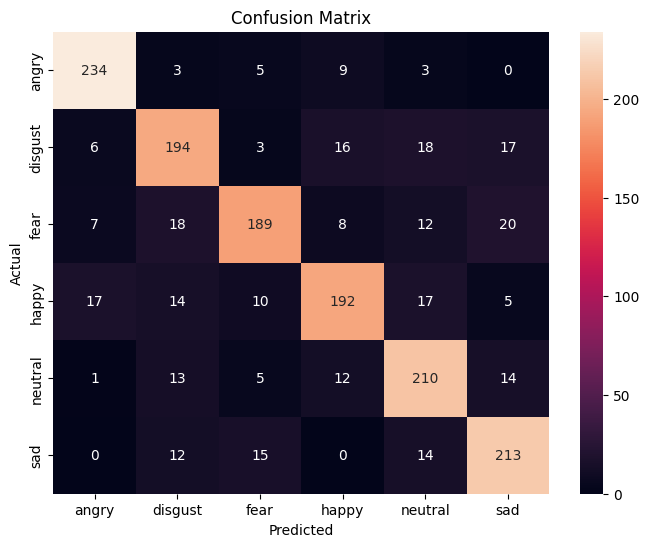

In [ ]:
# ==========================================
# STEP 1: Install Libraries
# ==========================================
!pip install librosa xgboost --quiet

import numpy as np
import pandas as pd
import librosa
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample
from xgboost import XGBClassifier

# ==========================================
# STEP 2: Mount Drive
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

# ==========================================
# STEP 3: Extract ZIP
# ==========================================
zip_path = "/content/drive/MyDrive/CREMA-D.zip"  # Change if needed
extract_path = "/content/CREMA-D"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted!")

# ==========================================
# STEP 4: Automatically Find WAV Folder
# ==========================================
wav_folder = None

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".wav"):
            wav_folder = root
            break
    if wav_folder:
        break

if wav_folder is None:
    raise ValueError("❌ No WAV files found. Check ZIP file.")

print("✅ WAV Folder Found:", wav_folder)

# ==========================================
# STEP 5: Feature Extraction
# ==========================================
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=None)

        mfcc = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40).T, axis=0)
        chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sr).T, axis=0)
        mel = np.mean(librosa.feature.melspectrogram(y=audio, sr=sr).T, axis=0)

        return np.hstack((mfcc, chroma, mel))
    except:
        return None

# ==========================================
# STEP 6: Load Dataset
# ==========================================
features = []
labels = []

emotion_dict = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad"
}

for file in tqdm(os.listdir(wav_folder)):
    if file.endswith(".wav"):
        parts = file.split("_")

        if len(parts) > 2:
            emotion_code = parts[2]
            emotion = emotion_dict.get(emotion_code)

            if emotion:
                file_path = os.path.join(wav_folder, file)
                feature = extract_features(file_path)

                if feature is not None:
                    features.append(feature)
                    labels.append(emotion)

print("✅ Total Samples:", len(features))

if len(features) == 0:
    raise ValueError("❌ No features extracted. Something wrong with folder path.")

# ==========================================
# STEP 7: Create DataFrame
# ==========================================
X = np.array(features)
y = np.array(labels)

df = pd.DataFrame(X)
df["label"] = y

print("\nClass Distribution Before Balancing:")
print(df["label"].value_counts())

# ==========================================
# STEP 8: Balance Dataset
# ==========================================
max_count = df["label"].value_counts().max()

balanced_data = []

for label in df["label"].unique():
    class_df = df[df["label"] == label]

    upsampled = resample(
        class_df,
        replace=True,
        n_samples=max_count,
        random_state=42
    )

    balanced_data.append(upsampled)

balanced_df = pd.concat(balanced_data, ignore_index=True)

print("\nClass Distribution After Balancing:")
print(balanced_df["label"].value_counts())

# ==========================================
# STEP 9: Prepare Data
# ==========================================
X_balanced = balanced_df.drop(columns=["label"]).values
y_balanced = balanced_df["label"].values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_balanced)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ==========================================
# STEP 10: Train Model (High Accuracy)
# ==========================================
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

# ==========================================
# STEP 11: Evaluate
# ==========================================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n🔥 FINAL MODEL ACCURACY:", round(accuracy * 100, 2), "%\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# ==========================================
# STEP 12: Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()